In [2]:
import os
import time
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

import barostat_parameters
from barostat_utils import (
    estimate_initial_box_vel_y,
    estimate_initial_box_vel_y_accurate,
    update_box_y_thermodynamic,
)
from graph_utils import prepare_traj
from pressure import compute_per_particle_forces
from simulator_model import Model as VelocityModel
from training_utils import (
    ModelInputs,
    huber_loss,
)
from utils import (
    build_velocity_graph_correction,
    calc_p_ratio_box_tensor,
    get_correct_edge_attr,
    load_and_split_dataset
)


### Load Data

In [ ]:
dataset_type = "node_optimized" # "node_optimized" | "stiff_optimized"
if dataset_type not in {"node_optimized", "stiff_optimized"}:
    raise ValueError(f"Incorrect data type, expected 'node_optimized' or 'stiff_optimized', got {dataset_type}. ")

poisson_buckets = [
    {"max": 0.1, "count": 100},                # P < 0.1
    {"min": 0.1, "max": 0.2, "count": 100},    # 0.1 <= P < 0.2
    {"min": 0.2, "count": 200}                 # P >= 0.2
]

train_files, val_files, test_files = load_and_split_dataset(
    registry_path="./data/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.7, 0.15, 0.15),
    seed=42
)

# Load actual data
data = {
    'train': {},
    'val' : {},
    'test' : {},
}

print("Loading data...")
for key in data.keys():
    if key == 'train':
        data[key] = [torch.load(file, weights_only=False) for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        data[key] = [torch.load(file, weights_only=False) for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        data[key] = [torch.load(file, weights_only=False) for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

print("\nPreparing data...")
for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        prepared_sim = prepare_traj(sim, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"\nTrain data: {len(data['train'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")


Loading data...


test  data: 100%|██████████| 60/60 [00:02<00:00, 20.73it/s]



Preparing data...


test  data: 100%|██████████| 60/60 [00:06<00:00,  9.78it/s]


Train data: 280 sims.
Val data:   60 sims.
Test data:  60 sims.


#### Show $\nu$ distribution

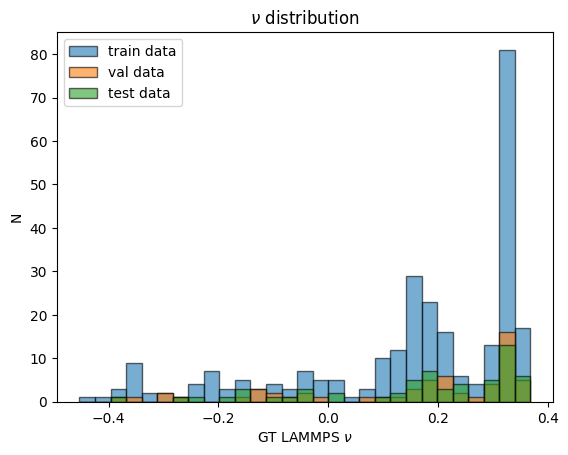

In [5]:
def visualize_nu_disribution(data: Dict):
    ps = {}
    all_values = []

    for data_type, sims in data.items():
        ps[data_type] = [calc_p_ratio_box_tensor(sim).item() for sim in sims]
        all_values.extend(ps[data_type])

    min_val = min(all_values)
    max_val = max(all_values)
    common_bins = np.linspace(min_val, max_val, 30) 

    for data_type, values in ps.items():
        plt.hist(
        values, 
        bins=common_bins, 
        edgecolor='black', 
        alpha=0.6, 
        label=f"{data_type} data"
    )

    plt.title("$\\nu$ distribution")
    plt.xlabel("GT LAMMPS $\\nu$")
    plt.ylabel("N")
    plt.legend()
    plt.show()

visualize_nu_disribution(data)


### Training GNN simulator

#### Initiaize Velocity simulator

In [7]:
mp_layers = 2
mlp = 3
hidden_size = 128
history = 3
device = "cuda"

init_graph = build_velocity_graph_correction(
    input_graphs=[data['train'][0][i].cpu().detach() for i in range(history + 1)],
    total_velocity=False,
    panic_at_positions=False
).to(device)

gnn_simulator = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)


#### One-step Training loop

Here we train on a portion of training data with high Poisson's ratio, either $\nu > 0.1$ or $\nu > 0.2$.

In [9]:
model_save_directory = os.path.join("./trained_models", f"{dataset_type}", "OST")
if not os.path.exists(model_save_directory):
    os.makedirs(model_save_directory, exist_ok=True)

epochs = 100
freeze_norm_epoch = 5
train_sims = 100
val_sims = 20
train_limit = 15
accumulation_steps = 10
learning_rate = 1e-3
gamma = 0.995

# Limit training data to high Poisson's ratio simulation
poisson_threshold = 0.1
training_data = [sim for sim in data['train'] if calc_p_ratio_box_tensor(sim) >= poisson_threshold][:train_sims]
print(f"Using {len(training_data)} simulations with Poisson's ratio >= {poisson_threshold} for training. ")

# Validation data can be full Poisson's ratio range

optimizer = torch.optim.Adam(gnn_simulator.parameters(), lr=learning_rate, weight_decay=0.0)
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma, last_epoch=-1)

optimizer.zero_grad()
for epoch in range(epochs):
    t_start = time.perf_counter()

    if epoch == freeze_norm_epoch:
        gnn_simulator.node_normalizer.frozen = True
        gnn_simulator.edge_normalizer.frozen = True
        gnn_simulator.output_normalizer.frozen = True

    total_acc_loss = 0
    total_val_loss = 0
    total_val_pos_mse = 0
    train_samples = 0
    val_samples = 0

    gnn_simulator.train()
    for sim in training_data:
        starting_points = [i for i in range(train_limit)]

        for i, idx in enumerate(starting_points):
            indices = [step + idx for step in range(history + 1)]
            target_idx = history + 1 + idx


            input_graphs_raw = [sim[k].detach().cpu() for k in indices]

            # Construct input graph
            input_graph = build_velocity_graph_correction(input_graphs_raw, panic_at_positions=False).to(device)

            # Construct ModelInputs
            model_inputs = ModelInputs(
                input_graphs_raw[-2].to(device) if history > 0 else input_graphs_raw[-1].to(device),
                input_graphs_raw[-1].to(device),
                sim[target_idx].to(device)
            )

            # Forward and Loss
            model_output = gnn_simulator(input_graph, is_training=True)
            acc_loss = huber_loss(gnn_simulator, model_output, model_inputs, is_training=True)

            # Backward
            loss_for_backward = acc_loss / accumulation_steps
            loss_for_backward.backward()

            # Optimization
            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(gnn_simulator.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            total_acc_loss += acc_loss.item()
            train_samples += 1

        optimizer.step()
        optimizer.zero_grad()

    # Validation
    with torch.no_grad():
        gnn_simulator.eval()
        for val_sim in data['val'][:val_sims]:
            
            starting_points = [i for i in range(train_limit)]

            for idx in starting_points:
                indices = [step + idx for step in range(history + 1)]
                target_idx = history + 1 + idx

                input_graphs_raw = [val_sim[k].detach().cpu() for k in indices]

                input_graph = build_velocity_graph_correction(input_graphs_raw, panic_at_positions=False).to(device) 

                val_inputs = ModelInputs(
                    input_graphs_raw[-2].to(device) if history > 0 else input_graphs_raw[-1].to(device),
                    input_graphs_raw[-1].to(device),
                    val_sim[target_idx].to(device),
                )

                # Forward and Loss
                model_output = gnn_simulator(input_graph, is_training=False)
                val_loss = huber_loss(gnn_simulator, model_output, val_inputs, is_training=False)

                # Update to next state and check position MSE
                pred_graph = gnn_simulator.update(val_inputs, model_output)
                pos_mse = torch.nn.functional.mse_loss(pred_graph.pos, val_sim[target_idx].to(device).pos)

                total_val_loss += val_loss.item()
                total_val_pos_mse += pos_mse.item()
                val_samples += 1

    lr_scheduler.step()

    # Statistics
    avg_train_loss = total_acc_loss / train_samples
    avg_val_loss = total_val_loss / val_samples
    avg_val_pos_mse = total_val_pos_mse / val_samples

    # Save model
    if epoch % 1 == 0:
        gnn_simulator.save_checkpoint(os.path.join(model_save_directory, f"checkpoint_epoch_{epoch}.pt"))

    t_stop = time.perf_counter()
    print(
        f"Epoch {epoch + 1:>3} | "
        f"Train Loss: {avg_train_loss:.3e} | "
        f"Val Loss: {avg_val_loss:.3e} | "
        f"Val Pos MSE: {avg_val_pos_mse:.3e} | "
        f"Time: {t_stop - t_start:.2f} s"
    )

gnn_simulator.save_checkpoint(os.path.join(model_save_directory, f"model_P>{poisson_threshold}_h{history}_nl{mp_layers}_mlp{mlp}_epochs{epochs}.pt"))

Using 100 simulations with Poisson's ratio >= 0.1 for training. 
Epoch   1 | Train Loss: 1.777e-01 | Val Loss: 2.647e-01 | Val Pos MSE: 1.340e-12 | Time: 5.96 s
Epoch   2 | Train Loss: 1.740e-01 | Val Loss: 2.592e-01 | Val Pos MSE: 1.277e-12 | Time: 5.89 s
Epoch   3 | Train Loss: 1.639e-01 | Val Loss: 2.527e-01 | Val Pos MSE: 1.196e-12 | Time: 5.83 s
Epoch   4 | Train Loss: 1.680e-01 | Val Loss: 2.702e-01 | Val Pos MSE: 1.311e-12 | Time: 5.84 s
Epoch   5 | Train Loss: 1.617e-01 | Val Loss: 2.559e-01 | Val Pos MSE: 1.238e-12 | Time: 5.92 s
Epoch   6 | Train Loss: 1.643e-01 | Val Loss: 2.511e-01 | Val Pos MSE: 1.191e-12 | Time: 5.99 s
Epoch   7 | Train Loss: 1.623e-01 | Val Loss: 2.526e-01 | Val Pos MSE: 1.199e-12 | Time: 6.01 s
Epoch   8 | Train Loss: 1.575e-01 | Val Loss: 2.577e-01 | Val Pos MSE: 1.250e-12 | Time: 6.02 s
Epoch   9 | Train Loss: 1.535e-01 | Val Loss: 2.509e-01 | Val Pos MSE: 1.173e-12 | Time: 6.21 s
Epoch  10 | Train Loss: 1.499e-01 | Val Loss: 2.567e-01 | Val Pos MSE: 

#### Multi-step training loop

In [10]:
model_save_directory = f"./trained_models/{dataset_type}/MST"
if not os.path.exists(model_save_directory):
    os.makedirs(model_save_directory, exist_ok=True)

epochs = 100
train_limit: int = 15
max_rollout_steps: int = 10
fresh: bool = True
freeze_norm_epoch: int = 5
learning_rate: float = 1e-3
gamma = 0.995

# Limit training data to high Poisson's ratio simulation
poisson_threshold = 0.1
training_data = [sim for sim in data['train'] if calc_p_ratio_box_tensor(sim) >= poisson_threshold][:train_sims]
print(f"Using {len(training_data)} simulations with Poisson's ratio >= {poisson_threshold} for training. ")

barostat_config = barostat_parameters.node_optimizated if dataset_type == "node_optimized" else barostat_parameters.stiff_optimized

gnn_simulator.train()
params = filter(lambda p: p.requires_grad, gnn_simulator.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=0.0)
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma, last_epoch=-1)


optimizer.zero_grad()
for epoch in range(epochs):
    t_start = time.perf_counter()

    if fresh:
        if epoch < 10:
            rollout_steps = 1
        elif epoch >= 10 and epoch < 20:
            rollout_steps = 2
        elif epoch >= 20 and epoch < 30:
            rollout_steps = 3
        elif epoch >= 30 and epoch < 40:
            rollout_steps = 5
        elif epoch >= 40 and epoch < 50:
            rollout_steps = 8
        else:
            rollout_steps = max_rollout_steps

    # Trackers
    total_acc_loss = 0
    train_samples = 0

    # Freeze normalizers
    if epoch == freeze_norm_epoch:
        gnn_simulator.node_normalizer.frozen = True
        gnn_simulator.edge_normalizer.frozen = True
        gnn_simulator.output_normalizer.frozen = True

    for sim in training_data:
        # Get equilibrium bond lengths
        r0 = sim[0].edge_attr[:, -2]
        
        starting_points = [i for i in range(train_limit)]
        dump_period = barostat_config["default_skip"]

        for start_idx in starting_points:
            optimizer.zero_grad()

            indices = [step + start_idx for step in range(history + 1)]
            current_window_graphs = [sim[k].detach().to(device) for k in indices]

            b0 = current_window_graphs[-2].box_tensor[0]
            b1 = current_window_graphs[-1].box_tensor[0]
            box_compression_factor = b1 / b0

            if len(current_window_graphs) < 3:
                current_box_vel_y = estimate_initial_box_vel_y(
                    current_window_graphs[-2],
                    current_window_graphs[-1],
                    dump_period * barostat_config["dt"],
                )
            elif len(current_window_graphs) >= 3:
                current_box_vel_y = estimate_initial_box_vel_y_accurate(
                    current_window_graphs[-3],
                    current_window_graphs[-2],
                    current_window_graphs[-1],
                    dump_period * barostat_config["dt"],
                )
            else:
                raise Exception(f"Window size is too small : {len(current_window_graphs)}")


            rollout_loss = 0
            for step in range(rollout_steps):
                target_idx = history + 1 + start_idx + step
                target_graph = sim[target_idx].to(device)

                input_graph = build_velocity_graph_correction(current_window_graphs).to(device)

                model_inputs = ModelInputs(
                    current_window_graphs[-2],
                    current_window_graphs[-1],
                    target_graph,
                )

                model_output = gnn_simulator(input_graph, is_training=True)
                pred_graph_next = gnn_simulator.update(model_inputs, model_output)

                step_loss = huber_loss(gnn_simulator, model_output, model_inputs, is_training=True)
                rollout_loss += step_loss

                dt = barostat_config["dt"]  # lammps dt
                W_y = barostat_config["C_coupling"] * pred_graph_next.num_nodes * ((dump_period * dt) ** 2)
                damping = barostat_config["damping"] * pred_graph_next.num_nodes * (dump_period * dt)

                new_lx = pred_graph_next.box_tensor[0] * box_compression_factor
                new_ly, new_vel_y = update_box_y_thermodynamic(
                    positions=pred_graph_next.pos,
                    edge_index=model_inputs.cur_graph.edge_index,
                    edge_attr=model_inputs.cur_graph.edge_attr,
                    current_box=model_inputs.cur_graph.box_tensor,
                    r0=r0.to(pred_graph_next.pos.device),
                    box_vel_y=current_box_vel_y,  # Use ESTIMATED velocity
                    W_y=W_y,
                    damping=damping,
                    stride_dt=dump_period * dt,
                    target_pressure=barostat_config["target_pressure"],
                    temperature=barostat_config["temperature"],
                )

                new_box_tensor = torch.stack([new_lx, new_ly])
                current_box_vel_y = new_vel_y

                # Add new box and update edge_attr
                pred_graph_next.box_tensor = new_box_tensor
                pred_graph_next.edge_attr = get_correct_edge_attr(
                    pred_graph_next,
                    recompute_stiff=False,
                    panic_at_nontensor_box=True,
                )
                pred_graph_next.forces = compute_per_particle_forces(pred_graph_next, r0=r0.to(pred_graph_next.pos.device))

                pred_graph_next_detached = pred_graph_next.detach()

                # Update window: shift left, append new prediction
                current_window_graphs.pop(0)
                current_window_graphs.append(pred_graph_next_detached)

            final_loss = rollout_loss / rollout_steps
            final_loss.backward()

            # Clip gradients (essential for GNNs in physics)
            torch.nn.utils.clip_grad_norm_(gnn_simulator.parameters(), max_norm=1.0)
            optimizer.step()

            total_acc_loss += final_loss.item()
            train_samples += 1

    gnn_simulator.save_checkpoint(os.path.join(model_save_directory, f"checkpoint_epoch_{epoch}.pt"))

    total_acc_loss /= train_samples
    lr_scheduler.step()
    t_stop = time.perf_counter()
    print(f"Epoch {epoch:<3} | steps: {rollout_steps:<2} | loss: {total_acc_loss:.4e} | {t_stop - t_start:.2f} s.")


Using 100 simulations with Poisson's ratio >= 0.1 for training. 
Epoch 0   | steps: 1  | loss: 1.7519e-01 | 8.33 s.
Epoch 1   | steps: 1  | loss: 1.7521e-01 | 7.64 s.
Epoch 2   | steps: 1  | loss: 1.7229e-01 | 7.65 s.
Epoch 3   | steps: 1  | loss: 1.7130e-01 | 7.56 s.
Epoch 4   | steps: 1  | loss: 1.6891e-01 | 7.69 s.
Epoch 5   | steps: 1  | loss: 1.6714e-01 | 7.81 s.
Epoch 6   | steps: 1  | loss: 1.6554e-01 | 7.69 s.
Epoch 7   | steps: 1  | loss: 1.6287e-01 | 7.95 s.
Epoch 8   | steps: 1  | loss: 1.5993e-01 | 7.80 s.
Epoch 9   | steps: 1  | loss: 1.5728e-01 | 8.02 s.
Epoch 10  | steps: 2  | loss: 4.1386e-01 | 13.78 s.
Epoch 11  | steps: 2  | loss: 4.0699e-01 | 13.94 s.
Epoch 12  | steps: 2  | loss: 4.0827e-01 | 13.94 s.
Epoch 13  | steps: 2  | loss: 4.0081e-01 | 13.84 s.
Epoch 14  | steps: 2  | loss: 3.9947e-01 | 13.95 s.
Epoch 15  | steps: 2  | loss: 3.9623e-01 | 13.86 s.
Epoch 16  | steps: 2  | loss: 3.9075e-01 | 14.10 s.
Epoch 17  | steps: 2  | loss: 3.8929e-01 | 13.57 s.
Epoch 18 

KeyboardInterrupt: 

#### Save trained simulator model

In [ ]:
gnn_simulator.save_checkpoint(os.path.join(model_save_directory, f"model_h{history}_nl{mp_layers}_mlp{mlp}_epochs{epochs}.pt"))